# Dataset Validation
Validação inicial da evidência e qualidade dos dados.

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
events = pl.read_parquet('../data/processed/parsed_events.parquet')
events.head()

timestamp,status_code,host,method,source_ip,user_agent,invoice_id,site_id,auth_token
datetime[μs],i32,str,str,str,str,i64,str,str
2020-12-01 00:16:00,201,"""mercadolibre.com""","""GET""","""27.0.2.178""","""Mozilla/5.0 (Windows NT 10.0) …",229933235,"""MeliMX""","""ATUSER-ID-jaxsonbuyer"""
2020-12-01 00:32:00,200,"""mercadolibre.com""","""GET""","""27.0.2.110""","""Mozilla/5.0 (Windows NT 10.0; …",118825298,"""MeliAR""","""ATUSER-ID-ambrosebuyer"""
2020-12-01 00:11:00,400,"""mercadolibre.com""","""GET""","""27.0.3.167""","""Mozilla/5.0 (Windows NT 10.0) …",118824252,"""MeliCO""","""ATUSER-ID-toolsuser"""
2020-12-01 00:15:00,401,"""mercadolibre.com""","""GET""","""27.0.4.205""","""Mozilla/5.0 (Windows NTÊx.y; W…",229933223,"""MeliMX""","""ATUSER-ID-sekanibuyer"""
2020-12-01 00:25:00,401,"""mercadolibre.com""","""GET""","""27.0.1.229""","""Mozilla/5.0 (Windows NT 10.0; …",118822077,"""MeliMX""","""ATUSER-ID-candyuser"""


In [3]:
events.schema

Schema([('timestamp', Datetime(time_unit='us', time_zone=None)),
        ('status_code', Int32),
        ('host', String),
        ('method', String),
        ('source_ip', String),
        ('user_agent', String),
        ('invoice_id', Int64),
        ('site_id', String),
        ('auth_token', String)])

In [4]:
events.select([
 pl.col('timestamp').min().alias('first_seen'),
 pl.col('timestamp').max().alias('last_seen')
])

first_seen,last_seen
datetime[μs],datetime[μs]
2020-10-01 00:00:00,2020-12-31 23:59:00


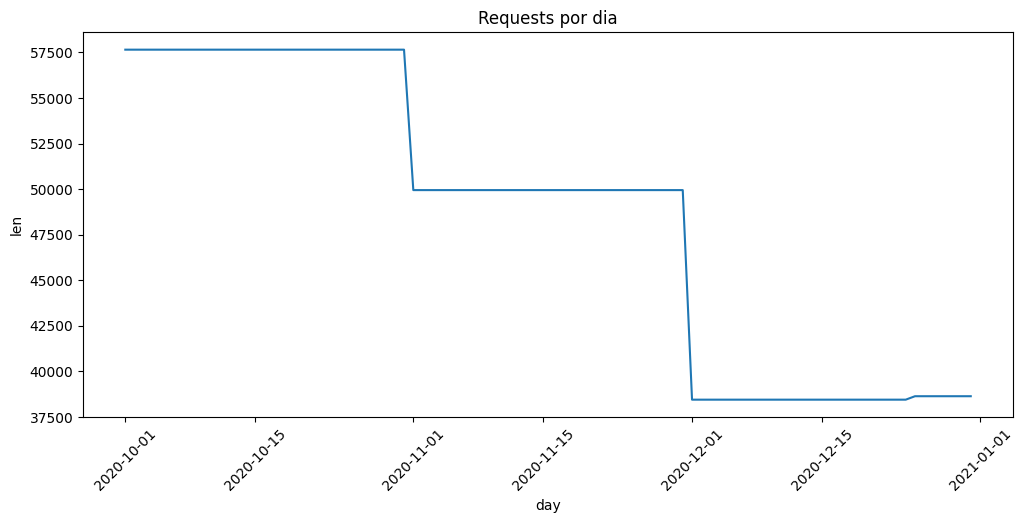

In [5]:
daily=(events.with_columns(pl.col("timestamp").dt.date().alias("day"))
.group_by("day").len().sort("day").to_pandas())
plt.figure(figsize=(12,5))
sns.lineplot(data=daily,x="day",y="len")
plt.title("Requests por dia")
plt.xticks(rotation=45)
plt.show()

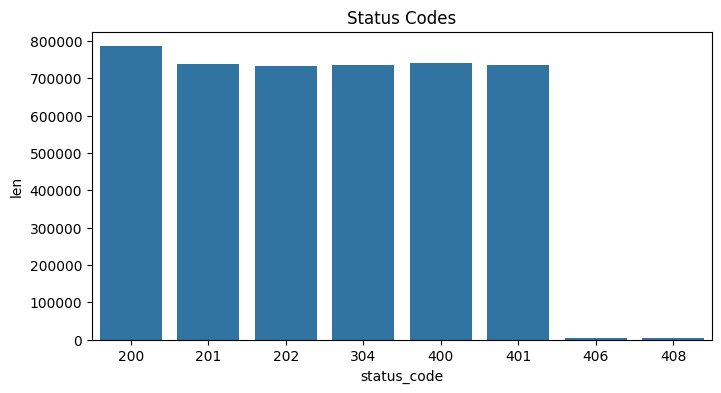

In [6]:
status=(events.group_by("status_code").len().sort("len",descending=True).to_pandas())
plt.figure(figsize=(8,4))
sns.barplot(data=status,x="status_code",y="len")
plt.title("Status Codes")
plt.show()